In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv(r'C:\Users\Asus\Desktop\project\final\model\input_data\tabular\df_condo_only.csv')

print(f"ขนาดข้อมูล: {df.shape}")
df.head()

ขนาดข้อมูล: (14722, 24)


,id,name,district,lat,long,sale_price,bedrooms,bathrooms,internal_area,floors,...,has_security,has_cctv,has_pool,has_sauna,has_gym,has_garden_bbq,has_playground,has_shop_on_premise,has_restaurant_on_premise,has_wifi
0,1041,Suan Thon Park Condo,Thung Khru,13.652504,100.487825,1650000,2,1,56.0,12,...,1,1,0,0,0,0,0,0,0,0
1,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1550000,1,1,28.0,8,...,1,1,1,0,1,1,1,1,0,1
2,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1187000,1,1,30.0,8,...,1,1,1,0,1,1,1,1,0,1
3,795,Origins Rama 2,Chom Thong,13.654157,100.423897,2600000,2,2,60.0,8,...,1,1,1,0,1,1,1,1,0,1
4,795,Origins Rama 2,Chom Thong,13.654157,100.423897,1187000,1,1,30.0,8,...,1,1,1,0,1,1,1,1,0,1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


print("ขั้นตอนเตรียมข้อมูล")
# Drop column ที่ไม่นำเข้า model
drop_cols = ['sale_price', 'name', 'id', 'lat', 'long',]
existing_drop = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=existing_drop)
y = np.log1p(df['sale_price']) 

# แบ่งข้อมูลเป็น train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One Hot Encoder แปลงข้อมูลตัวอักษรให้เป็นตัวเลข
categorical_cols = ['district']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
print("Hotend เรียบร้อย")

ขั้นตอนเตรียมข้อมูล
Hotend เรียบร้อย


In [3]:
# ตั้งค่า Params สำหรับ Grid search

model_params = {
    'Ridge': {
        'model': Ridge(),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    },
    'ElasticNet': {
        'model': ElasticNet(),
        'params': {
            'regressor__alpha': [0.01, 0.1, 1.0, 10.0],
            'regressor__l1_ratio': [0.2, 0.4, 0.6, 0.8]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'regressor__n_neighbors': [3, 5, 10, 20, 30],
            'regressor__weights': ['uniform', 'distance'],
            'regressor__p': [1, 2]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200, 300, 500],
            'regressor__max_depth': [10, 20, 30, None],
            'regressor__min_samples_leaf': [1, 2, 4, 8],
            'regressor__max_features': ['sqrt', 'log2', 0.5]
        }
    },
    'ExtraTrees': {
        'model': ExtraTreesRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200, 300, 500],
            'regressor__max_depth': [10, 20, 30, None],
            'regressor__min_samples_leaf': [1, 2, 4, 8]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100, 200, 300, 500],
            'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'regressor__max_depth': [3, 4, 5, 6]
        }
    },
    'XGBoost': {
        'model': xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
        'params': {
            'regressor__n_estimators': [500, 1000, 2000, 3000],
            'regressor__learning_rate': [0.005, 0.01, 0.05, 0.1],
            'regressor__max_depth': [3, 5, 7, 9],
            'regressor__subsample': [0.6, 0.7, 0.8, 0.9]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'regressor__n_estimators': [500, 1000, 2000, 3000],
            'regressor__learning_rate': [0.005, 0.01, 0.05, 0.1],
            'regressor__num_leaves': [31, 50, 100, 200],
            'regressor__feature_fraction': [0.6, 0.7, 0.8, 0.9]
        }
    }
}
print("ตั้งค่า Params เรียบร้อย")

ตั้งค่า Params เรียบร้อย


Run Grid search...
Training Ridge...
  --> Done! R2: -0.3403 | MAE: 1,587,889 | MAPE: 24.39% | Used: 3.6s
Training ElasticNet...
  --> Done! R2: -1.6279 | MAE: 1,823,834 | MAPE: 28.26% | Used: 0.5s
Training KNN...
  --> Done! R2: 0.9110 | MAE: 707,236 | MAPE: 11.95% | Used: 11.4s
Training RandomForest...
  --> Done! R2: 0.9204 | MAE: 702,099 | MAPE: 11.63% | Used: 795.2s
Training ExtraTrees...
  --> Done! R2: 0.9287 | MAE: 654,926 | MAPE: 11.25% | Used: 770.6s
Training GradientBoosting...
  --> Done! R2: 0.9298 | MAE: 678,204 | MAPE: 11.44% | Used: 118.6s
Training XGBoost...
  --> Done! R2: 0.9334 | MAE: 667,638 | MAPE: 11.10% | Used: 249.3s
Training LightGBM...
  --> Done! R2: 0.9360 | MAE: 667,726 | MAPE: 11.29% | Used: 1645.9s

สรุปผลการเปรียบเทียบ (เรียงตามความแม่นยำ)
           Model   MAE (Baht)  MAPE (%)   Best R2  Training Time (s)
      ExtraTrees 6.549262e+05 11.253160  0.928662         770.588706
         XGBoost 6.676377e+05 11.102890  0.933359         249.278456
        Li

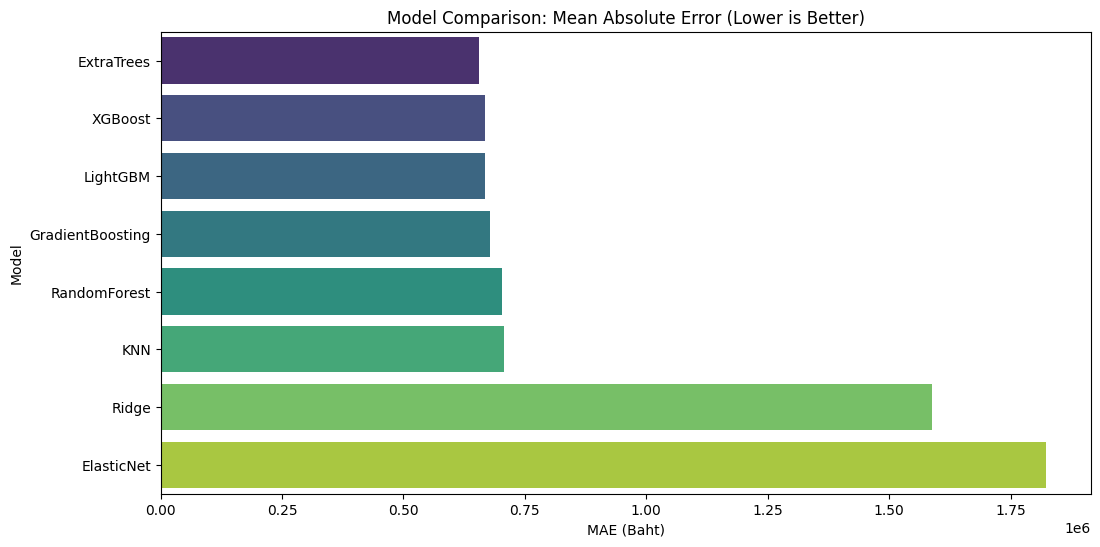

Best Model: ExtraTrees
Best Params
{'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 200}


In [4]:
# Run Grid search
results = []
print(f"Run Grid search...")

for model_name, mp in model_params.items():
    start_time = time.time()
    
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('regressor', mp['model'])])
    
    grid = GridSearchCV(clf, mp['params'], cv=3, scoring='r2', n_jobs=-1)
    
    print(f"Training {model_name}...")
    try:
        grid.fit(X_train, y_train)
        
        best_model = grid.best_estimator_
        y_pred_log = best_model.predict(X_test)
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_test)
        
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        duration = time.time() - start_time
        
        results.append({
            'Model': model_name,
            'Best R2': r2,
            'MAE (Baht)': mae,
            'MAPE (%)': mape,
            'Best Params': grid.best_params_,
            'Training Time (s)': duration
        })
        print(f"  --> Done! R2: {r2:.4f} | MAE: {mae:,.0f} | MAPE: {mape:.2f}% | Used: {duration:.1f}s")
        
    except Exception as e:
        print(f"  --> Error with {model_name}: {e}")

# แสดงผล Grid search
results_df = pd.DataFrame(results).sort_values(by='MAE (Baht)', ascending=True)

print("\n" + "="*70)
print("สรุปผลการเปรียบเทียบ (เรียงตามความแม่นยำ)")
print("="*70)
print(results_df[['Model', 'MAE (Baht)', 'MAPE (%)', 'Best R2', 'Training Time (s)']].to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='MAE (Baht)', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Mean Absolute Error (Lower is Better)')
plt.xlabel('MAE (Baht)')
plt.show()

if not results_df.empty:
    winner = results_df.iloc[0]
    print(f"Best Model: {winner['Model']}")
    print("Best Params")
    print(winner['Best Params'])